Load and explore the seaosn level Fangraphs batting data.

In [4]:
# Loading packages
import numpy as np
import pandas as pd
import arviz as az
import seaborn as sns
import matplotlib.pyplot as plt
import pymc as pm
from pathlib import Path
from scipy import stats

# Loading data
data_path = Path.cwd()
while not (data_path / "data" / "fangraphs" / "fg_hitters.csv").exists() and data_path != data_path.parent:
    data_path = data_path.parent

data_path = data_path / "data" / "fangraphs" / "fg_hitters.csv"

print(f"Loading data from {data_path}")
data = pd.read_csv(data_path)

Loading data from c:\Users\19175\Documents\personal\classes\LSE\ST451-Bayesian_ML\project\data\fangraphs\fg_hitters.csv


In [13]:
# Creating filtered versions of the full data

df = data[data["primary_pos"] != "P"][["IDfg",
             "Name", "Season", "Team", "Age", "primary_pos",
            "G", "PA", "OPS", "wOBA", "wRC+",
            "BsR", "Spd", "WAR", "K%", "BB%", "ISO", 
            "Hard%", "Hard%+", "EV", "LA", "Barrel%", "maxEV", 
            "LD%", "Z-Contact%", "Contact%", "O-Contact%",
            "O-Swing%", "Z-Swing%", "Zone%", "xwOBA",
            "BABIP"]]

C:\Users\19175\AppData\Local\Temp\ipykernel_29172\9725407.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.sum(g["wRC+"] * g["PA"]) / np.sum(g["PA"]))


Text(0.5, 1.0, 'Lineplot of Average wRC+ by Season and Position')

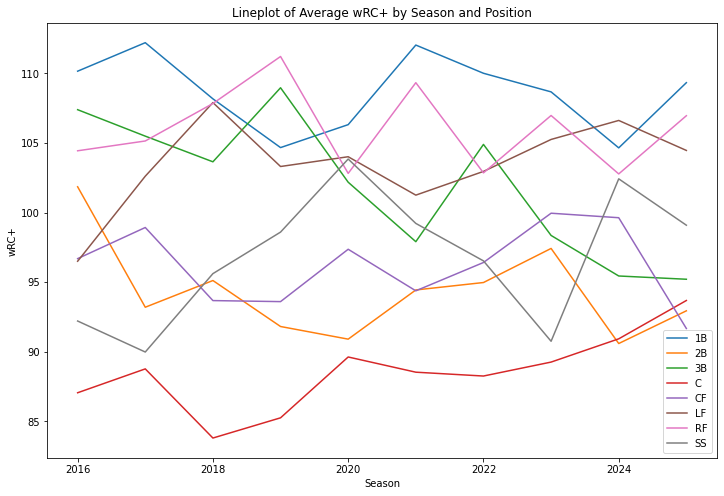

In [14]:
# Lineplot for average wRC+, weighted by PA, by season for every position in the data except pitchers
wrc_by_season_pos = (
	df.groupby(["Season", "primary_pos"])
	  .apply(lambda g: np.sum(g["wRC+"] * g["PA"]) / np.sum(g["PA"]))
	  .reset_index(name="wRC+")
)
plt.figure(figsize=(12, 8))
sns.lineplot(data=wrc_by_season_pos, x="Season", y="wRC+", hue="primary_pos")
plt.xlabel("Season")
plt.legend(loc="lower right")
plt.title("Lineplot of Average wRC+ by Season and Position")

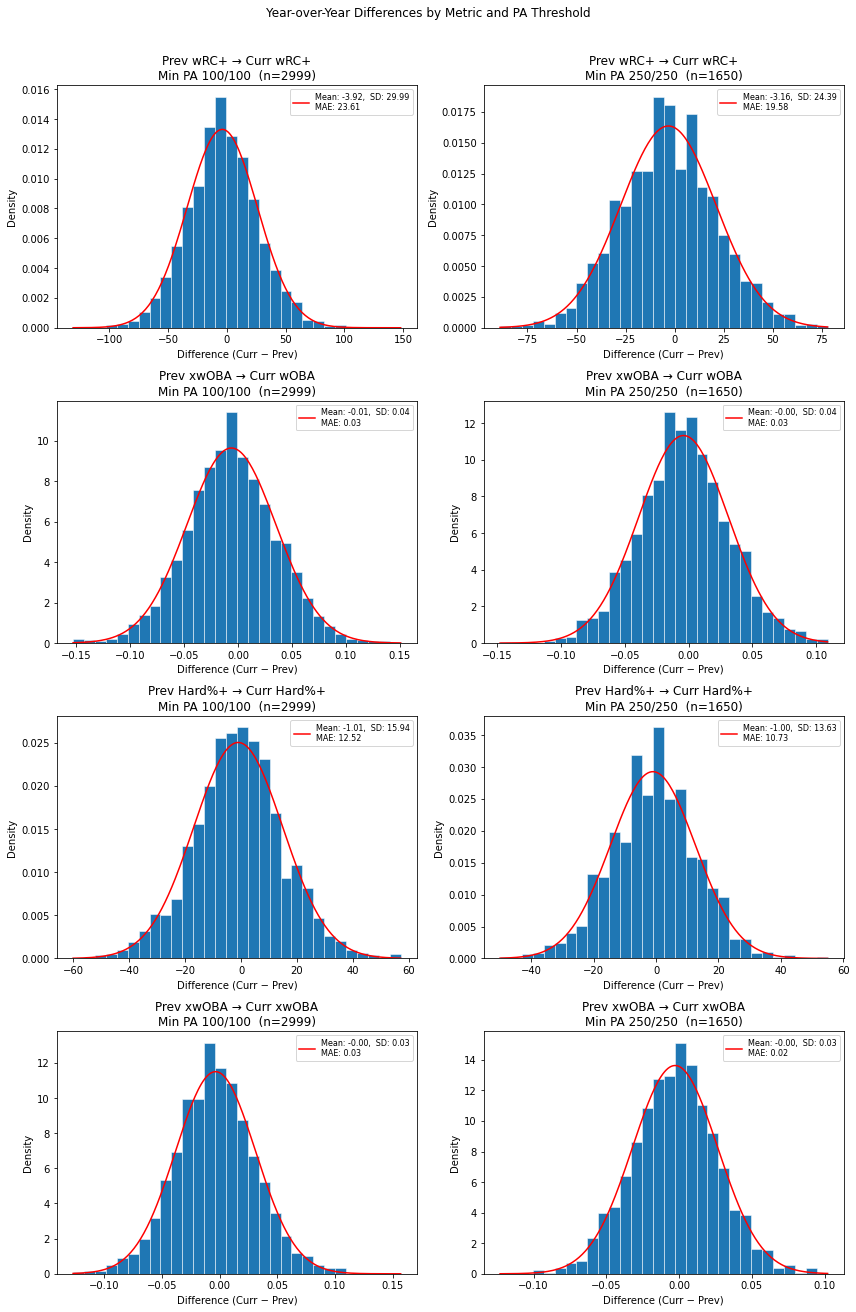

In [15]:
# Build year-over-year pairs (non-pitchers only)
df = data[(data["primary_pos"] != "P") | (data["Name"] == "Shohei Ohtani")][
    ["IDfg", "Season", "PA", "wRC+", "wOBA", "xwOBA", "Hard%+"]
].copy()

df_prev = df.rename(columns={"PA": "prev_PA", "wRC+": "prev_wRC+", "wOBA": "prev_wOBA",
                              "xwOBA": "prev_xwOBA", "Hard%+": "prev_Hard%+"})
df_prev["Season"] = df_prev["Season"] + 1

df_yoy = df.merge(df_prev[["IDfg", "Season", "prev_PA", "prev_wRC+", "prev_wOBA", "prev_xwOBA", "prev_Hard%+"]],
                  on=["IDfg", "Season"])

# Four comparisons: (prev col, curr col, label)
comparisons = [
    ("prev_wRC+",  "wRC+",   "Prev wRC+ → Curr wRC+"),
    ("prev_xwOBA", "wOBA",   "Prev xwOBA → Curr wOBA"),
    ("prev_Hard%+","Hard%+", "Prev Hard%+ → Curr Hard%+"),
    ("prev_xwOBA", "xwOBA",  "Prev xwOBA → Curr xwOBA"),
]

# Two PA filters: (min prev PA, min curr PA, label)
pa_filters = [
    (100, 100, "Min PA 100/100"),
    (250, 250, "Min PA 250/250"),
]

fig, axes = plt.subplots(4, 2, figsize=(12, 18))

for row, (prev_col, curr_col, comp_label) in enumerate(comparisons):
    for col_idx, (min_prev_pa, min_curr_pa, pa_label) in enumerate(pa_filters):
        ax = axes[row, col_idx]

        filtered = df_yoy[
            (df_yoy["prev_PA"] >= min_prev_pa) & (df_yoy["PA"] >= min_curr_pa)
        ].copy()
        diff = (filtered[curr_col] - filtered[prev_col]).dropna()
        mae = diff.abs().mean()

        ax.hist(diff, bins=30, edgecolor="white", linewidth=0.5, density=True)

        x = np.linspace(diff.min(), diff.max(), 200)
        ax.plot(x, stats.norm.pdf(x, diff.mean(), diff.std()), color="red", linewidth=1.5,
                label=f"Mean: {diff.mean():.2f},  SD: {diff.std():.2f}\nMAE: {mae:.2f}")

        ax.set_title(f"{comp_label}\n{pa_label}  (n={len(diff)})")
        ax.set_xlabel("Difference (Curr − Prev)")
        ax.set_ylabel("Density")
        ax.legend(fontsize=8)

fig.suptitle("Year-over-Year Differences by Metric and PA Threshold", y=1.01)
plt.tight_layout()
plt.show()


C:\Users\19175\AppData\Local\Temp\ipykernel_29172\717730209.py:25: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_yoy["played_next"] = df_yoy["played_next"].fillna(False)


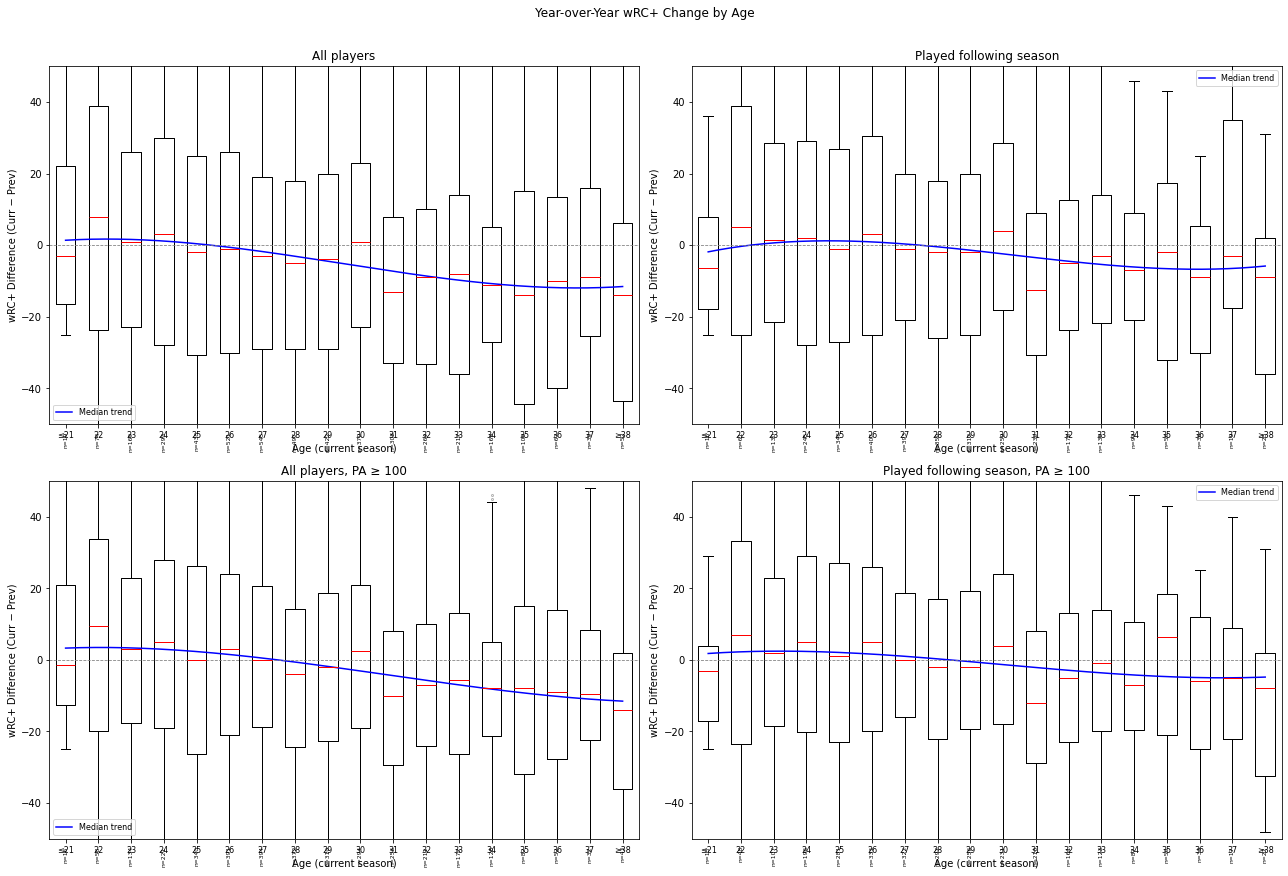

In [23]:
## Aging curves

# Build base dataframe (non-pitchers)
df = data[(data["primary_pos"] != "P") | (data["Name"] == "Shohei Ohtani")][
    ["IDfg", "Season", "Age", "PA", "wRC+"]
].copy()

# Build year-over-year pairs
df_prev = df[["IDfg", "Season", "PA", "wRC+"]].rename(
    columns={"PA": "prev_PA", "wRC+": "prev_wRC+"}
)
df_prev["Season"] = df_prev["Season"] + 1

df_yoy = df.merge(df_prev, on=["IDfg", "Season"])
df_yoy["wRC+_diff"] = df_yoy["wRC+"] - df_yoy["prev_wRC+"]

# Bin extreme ages (current age)
df_yoy["Age"] = df_yoy["Age"].apply(lambda a: "≤21" if a <= 21 else ("≥38" if a >= 38 else int(a)))

# Flag players who also appear the following season
next_season = df_yoy[["IDfg", "Season"]].copy()
next_season["Season"] = next_season["Season"] - 1
next_season["played_next"] = True
df_yoy = df_yoy.merge(next_season, on=["IDfg", "Season"], how="left")
df_yoy["played_next"] = df_yoy["played_next"].fillna(False)

specs = [
    {"pa": 0,   "next": False, "title": "All players"},
    {"pa": 0,   "next": True,  "title": "Played following season"},
    {"pa": 100, "next": False, "title": "All players, PA ≥ 100"},
    {"pa": 100, "next": True,  "title": "Played following season, PA ≥ 100"},
]

age_order = ["≤21"] + list(range(22, 38)) + ["≥38"]

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

for ax, spec in zip(axes.flat, specs):
    filtered = df_yoy[df_yoy["PA"] >= spec["pa"]].copy()
    if spec["next"]:
        filtered = filtered[filtered["played_next"]]

    positions = list(range(len(age_order)))
    groups = [filtered[filtered["Age"] == age]["wRC+_diff"].dropna().values for age in age_order]
    counts = [len(g) for g in groups]
    medians = [np.median(g) if len(g) > 0 else np.nan for g in groups]

    ax.boxplot(groups, positions=positions, widths=0.6,
               flierprops=dict(marker="o", markersize=2, alpha=0.3),
               medianprops=dict(color="red"))

    # Fit a polynomial curve through the medians (degree 3)
    valid = [(p, m) for p, m in zip(positions, medians) if not np.isnan(m)]
    valid_pos, valid_med = zip(*valid)
    coeffs = np.polyfit(valid_pos, valid_med, deg=3)
    x_smooth = np.linspace(min(valid_pos), max(valid_pos), 300)
    ax.plot(x_smooth, np.polyval(coeffs, x_smooth), color="blue", linewidth=1.5, label="Median trend")

    ax.set_xticks(positions)
    ax.set_xticklabels(age_order, fontsize=8)
    ax.set_ylim(-50, 50)

    for pos, count in zip(positions, counts):
        ax.text(pos, -52, f"n={count}", ha="center", va="top", fontsize=6, rotation=90)

    ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
    ax.set_title(spec["title"])
    ax.set_xlabel("Age (current season)")
    ax.set_ylabel("wRC+ Difference (Curr − Prev)")
    ax.legend(fontsize=8)

fig.suptitle("Year-over-Year wRC+ Change by Age", y=1.01)
plt.tight_layout()
plt.show()



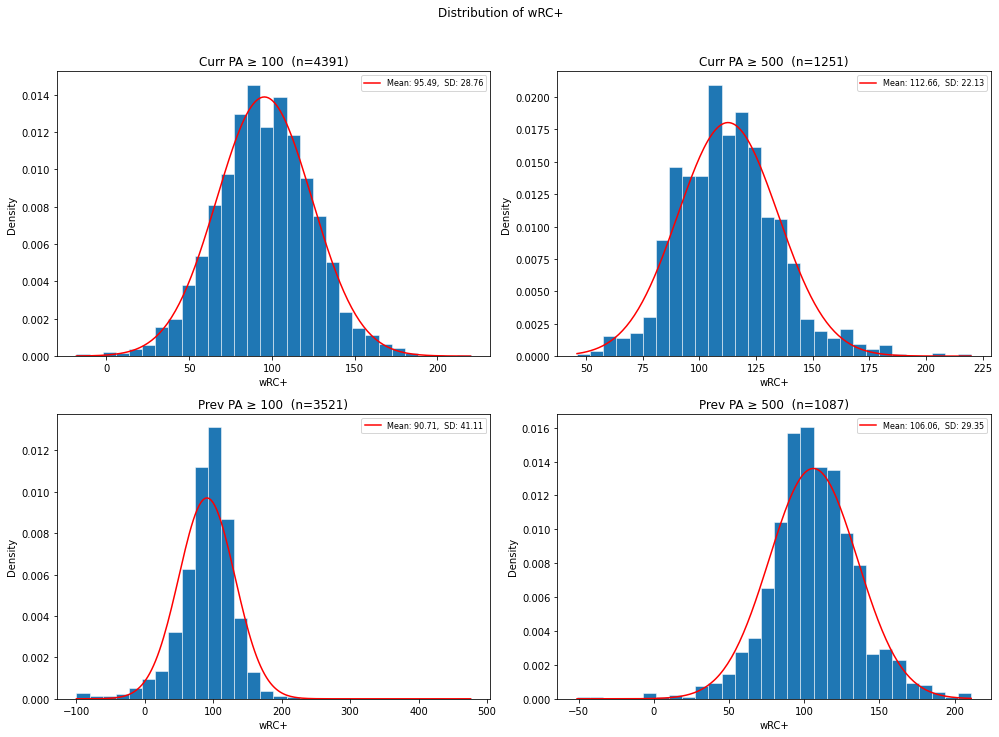

In [ ]:
# Distribution of wRC+

df = data[(data["primary_pos"] != "P") | (data["Name"] == "Shohei Ohtani")][
    ["IDfg", "Season", "PA", "wRC+"]
].copy()

# Build prev year PA
df_prev = df[["IDfg", "Season", "PA"]].rename(columns={"PA": "prev_PA"})
df_prev["Season"] = df_prev["Season"] + 1
df_yoy = df.merge(df_prev, on=["IDfg", "Season"], how="left")

specs = [
    {"filter": lambda d: d[d["PA"] >= 100],       "title": "Curr PA ≥ 100"},
    {"filter": lambda d: d[d["PA"] >= 500],      "title": "Curr PA ≥ 500"},
    {"filter": lambda d: d[d["prev_PA"] >= 100], "title": "Prev PA ≥ 100"},
    {"filter": lambda d: d[d["prev_PA"] >= 500], "title": "Prev PA ≥ 500"},
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, spec in zip(axes.flat, specs):
    filtered = spec["filter"](df_yoy)["wRC+"].dropna()

    ax.hist(filtered, bins=30, edgecolor="white", linewidth=0.5, density=True)

    x = np.linspace(filtered.min(), filtered.max(), 200)
    ax.plot(x, stats.norm.pdf(x, filtered.mean(), filtered.std()), color="red", linewidth=1.5,
            label=f"Mean: {filtered.mean():.2f},  SD: {filtered.std():.2f}")

    ax.set_title(f"{spec['title']}  (n={len(filtered)})")
    ax.set_xlabel("wRC+")
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)

fig.suptitle("Distribution of wRC+", y=1.02)
plt.tight_layout()
plt.show()



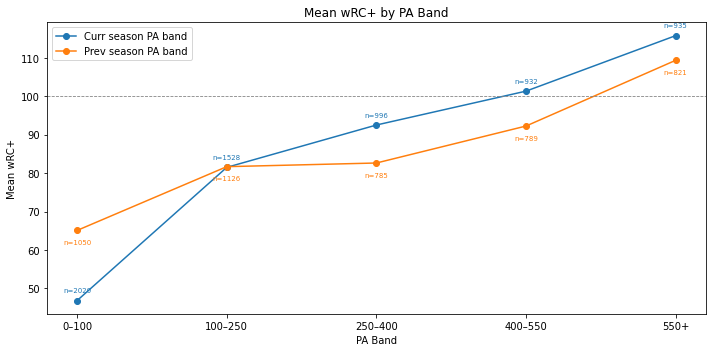

In [33]:
# wRC+ by plate appearance band

df = data[(data["primary_pos"] != "P") | (data["Name"] == "Shohei Ohtani")][
    ["IDfg", "Season", "PA", "wRC+"]
].copy()

# Build prev year PA
df_prev = df[["IDfg", "Season", "PA"]].rename(columns={"PA": "prev_PA"})
df_prev["Season"] = df_prev["Season"] + 1
df_yoy = df.merge(df_prev, on=["IDfg", "Season"], how="left")

bins = [0, 100, 250, 400, 550, np.inf]
labels = ["0–100", "100–250", "250–400", "400–550", "550+"]

df_yoy["curr_band"] = pd.cut(df_yoy["PA"],      bins=bins, labels=labels, right=False)
df_yoy["prev_band"] = pd.cut(df_yoy["prev_PA"], bins=bins, labels=labels, right=False)

curr_means = df_yoy.groupby("curr_band", observed=True)["wRC+"].mean()
prev_means = df_yoy.groupby("prev_band", observed=True)["wRC+"].mean()

curr_counts = df_yoy.groupby("curr_band", observed=True)["wRC+"].count()
prev_counts = df_yoy.groupby("prev_band", observed=True)["wRC+"].count()

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(labels, curr_means.reindex(labels), marker="o", label="Curr season PA band")
ax.plot(labels, prev_means.reindex(labels), marker="o", label="Prev season PA band")

# Annotate n= for each point
for i, label in enumerate(labels):
    ax.annotate(f"n={curr_counts[label]}", (i, curr_means[label]), textcoords="offset points",
                xytext=(0, 8), ha="center", fontsize=7, color="C0")
    ax.annotate(f"n={prev_counts[label]}", (i, prev_means[label]), textcoords="offset points",
                xytext=(0, -14), ha="center", fontsize=7, color="C1")

ax.set_xlabel("PA Band")
ax.set_ylabel("Mean wRC+")
ax.set_title("Mean wRC+ by PA Band")
ax.axhline(100, color="gray", linestyle="--", linewidth=0.8)
ax.legend()
plt.tight_layout()
plt.show()


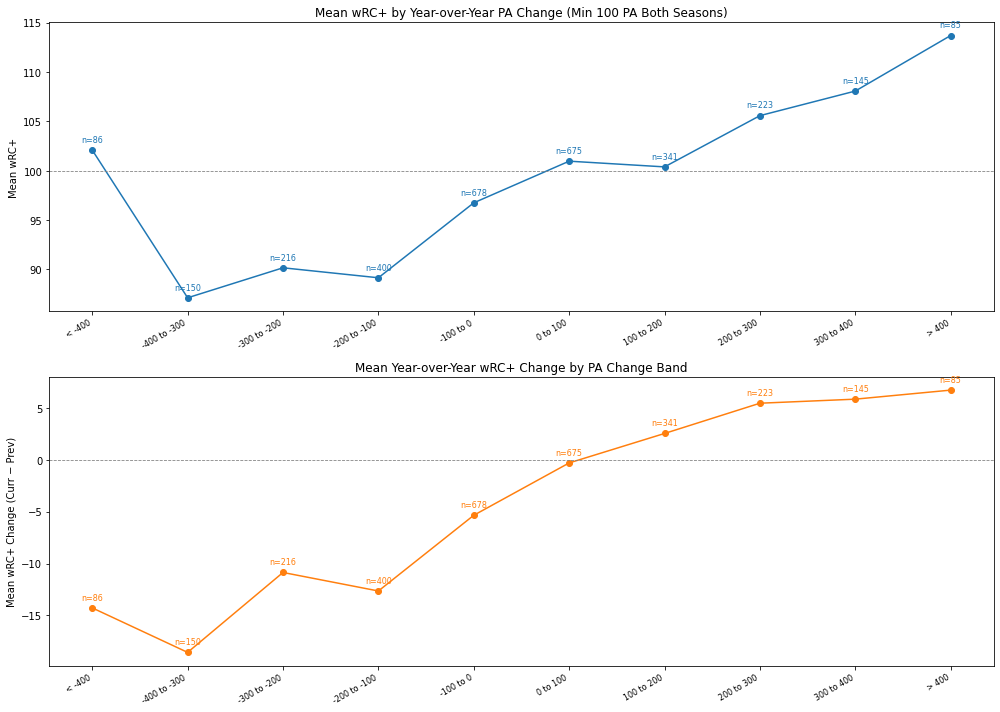

In [37]:
# wRC+ by year-over-year change in plate appearances

df = data[(data["primary_pos"] != "P") | (data["Name"] == "Shohei Ohtani")][
    ["IDfg", "Season", "PA", "wRC+"]
].copy()

df_prev = df[["IDfg", "Season", "PA", "wRC+"]].rename(columns={"PA": "prev_PA", "wRC+": "prev_wRC+"})
df_prev["Season"] = df_prev["Season"] + 1
df_yoy = df.merge(df_prev, on=["IDfg", "Season"])

df_yoy = df_yoy[(df_yoy["PA"] >= 100) & (df_yoy["prev_PA"] >= 100)]

df_yoy["PA_diff"] = df_yoy["PA"] - df_yoy["prev_PA"]
df_yoy["wRC+_diff"] = df_yoy["wRC+"] - df_yoy["prev_wRC+"]

bins = [-np.inf, -400, -300, -200, -100, 0, 100, 200, 300, 400, np.inf]
labels = ["< -400", "-400 to -300", "-300 to -200", "-200 to -100", "-100 to 0",
          "0 to 100", "100 to 200", "200 to 300", "300 to 400", "> 400"]

df_yoy["diff_band"] = pd.cut(df_yoy["PA_diff"], bins=bins, labels=labels)

band_wrc_means   = df_yoy.groupby("diff_band", observed=True)["wRC+"].mean()
band_delta_means = df_yoy.groupby("diff_band", observed=True)["wRC+_diff"].mean()
band_counts      = df_yoy.groupby("diff_band", observed=True)["wRC+"].count()

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Top: mean wRC+
ax = axes[0]
ax.plot(labels, band_wrc_means.reindex(labels), marker="o", color="C0")
for i, label in enumerate(labels):
    ax.annotate(f"n={band_counts[label]}", (i, band_wrc_means[label]), textcoords="offset points",
                xytext=(0, 8), ha="center", fontsize=8, color="C0")
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=30, ha="right", fontsize=8)
ax.set_ylabel("Mean wRC+")
ax.set_title("Mean wRC+ by Year-over-Year PA Change (Min 100 PA Both Seasons)")
ax.axhline(100, color="gray", linestyle="--", linewidth=0.8)

# Bottom: mean wRC+ change
ax = axes[1]
ax.plot(labels, band_delta_means.reindex(labels), marker="o", color="C1")
for i, label in enumerate(labels):
    ax.annotate(f"n={band_counts[label]}", (i, band_delta_means[label]), textcoords="offset points",
                xytext=(0, 8), ha="center", fontsize=8, color="C1")
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=30, ha="right", fontsize=8)
ax.set_ylabel("Mean wRC+ Change (Curr − Prev)")
ax.set_title("Mean Year-over-Year wRC+ Change by PA Change Band")
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)

plt.tight_layout()
plt.show()


